# SOTA Comparison: XLS-R (300M) and AST (87M) on MLADDC T2

This notebook trains and evaluates two SOTA models on the MLADDC T2 binary track:
- **Wav2Vec2 XLS-R 300M** (`facebook/wav2vec2-xls-r-300m`) — raw waveform input, multilingual SSL pretrained
- **Audio Spectrogram Transformer** (`MIT/ast-finetuned-audioset-10-10-0.4593`) - mel spectrogram input

Both are evaluated on the **same T2 test set** as MFAAN and CAFNet for a legitimate comparison.

**What is NOT changed from original models:**
- Pretrained weights are loaded as-is from HuggingFace
- Feature extraction front-ends are kept frozen
- Only the classification head is fine-tuned (+ top transformer layers for XLS-R)

**Key paths:**
- T2 raw audio: `/kaggle/input/datasets/artharking/mladdc-t2/T2/`
- T2 preprocessed (for AST): `/kaggle/input/datasets/piwoobeep/t2-processed/t2_features.npz`

In [2]:
# ==============================================================================
# CELL 1: Install dependencies
# ==============================================================================
!pip install transformers==4.40.0 accelerate==0.29.3 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 79.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 90.1 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [3]:
# ==============================================================================
# CELL 2: Imports and config
# ==============================================================================
import os, gc, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

import librosa
import soundfile as sf

from transformers import (
    Wav2Vec2Model,
    Wav2Vec2Processor,
    ASTModel,
    ASTFeatureExtractor,
    AutoFeatureExtractor,
)
from transformers import Wav2Vec2FeatureExtractor


from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, roc_curve
)
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# ── Paths ──────────────────────────────────────────────────────────────────────
T2_AUDIO_DIR  = Path('/kaggle/input/datasets/artharking/mladdc-t2/T2')
T2_CACHE      = Path('/kaggle/input/datasets/piwoobeep/t2-processed/t2_features.npz')
WORK_DIR      = Path('/kaggle/working')
MODELS_DIR    = WORK_DIR / 'sota_models'
MODELS_DIR.mkdir(exist_ok=True)

# ── Config ─────────────────────────────────────────────────────────────────────
SR            = 16000
DURATION      = 4.0
MAX_SAMPLES   = int(SR * DURATION)   # 64000
BATCH_XLR     = 8    # XLS-R is large — keep batch small
BATCH_AST     = 32
EPOCHS        = 5    # both models converge fast from pretrained weights
LR_XLR        = 1e-5 # very low — we're fine-tuning a large pretrained model
LR_AST        = 1e-4
WD            = 1e-4
ES_PAT        = 3
SEED          = 42
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(s=42):
    np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f'Device: {DEVICE}')
print(f'T2 audio dir exists: {T2_AUDIO_DIR.exists()}')
print(f'T2 cache exists:     {T2_CACHE.exists()}')

Device: cuda
T2 audio dir exists: True
T2 cache exists:     True


In [5]:
# ==============================================================================
# CELL 3: Discover T2 audio file paths and labels
#
# MLADDC T2 structure:
#   T2/
#     real/   lang_code/  *.wav
#     fake/   lang_code/  *.wav
# Labels: real=0, fake=1
# We use the same 70/15/15 split as NB1 (sorted by filename, seed 42)
# ==============================================================================

def load_split(split_name):
    split_dir = T2_AUDIO_DIR / split_name
    records = []
    for label_name, label_id in [('real', 0), ('deepfake', 1)]:
        label_dir = split_dir / label_name
        if not label_dir.exists():
            print(f'WARNING: {label_dir} not found')
            continue
        for fpath in sorted(label_dir.rglob('*.wav')):
            records.append({'path': str(fpath), 'label': label_id})
        for fpath in sorted(label_dir.rglob('*.flac')):
            records.append({'path': str(fpath), 'label': label_id})
    df = pd.DataFrame(records)
    real = int((df.label==0).sum()); deepfake = int((df.label==1).sum())
    print(f'  {split_name}: total={len(df):,}  real={real:,}  fake={deepfake:,}')
    return df

print('Loading T2 splits...')
df_train = load_split('train')
df_val   = load_split('val')
df_test  = load_split('test')

Loading T2 splits...
  train: total=134,400  real=44,800  fake=89,600
  val: total=16,800  real=5,600  fake=11,200
  test: total=16,800  real=5,600  fake=11,200


In [6]:
# ==============================================================================
# CELL 4: Shared evaluation utilities
# ==============================================================================
def compute_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return brentq(lambda x: 1 - x - interp1d(fpr, tpr)(x), 0, 1)

def evaluate_model(model, loader, device, model_type='xlr'):
    """Generic eval — works for XLS-R, AST."""
    model.eval()
    all_preds, all_labels, all_scores = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Eval', leave=False):
            labels = batch['label'].to(device)

            if model_type == 'xlr':
                input_values   = batch['input_values'].to(device)
                attention_mask = batch.get('attention_mask')
                if attention_mask is not None:
                    attention_mask = attention_mask.to(device)
                logits = model(input_values, attention_mask=attention_mask)

            elif model_type == 'ast':
                input_values = batch['input_values'].to(device)
                logits = model(input_values)

            elif model_type == 'feat':
                features = batch['features'].to(device)
                logits   = model(features)

            else:
                raise ValueError(f"Unknown model_type '{model_type}'. "
                                 f"Expected: 'xlr', 'ast', or 'feat'.")

            probs = F.softmax(logits, dim=1).cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(probs[:, 1])   # P(fake) as score

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)

    acc = accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_scores)
        eer = compute_eer(all_labels, all_scores)
    except Exception:
        auc = float('nan'); eer = float('nan')

    return {'acc': acc, 'auc': auc, 'eer': eer,
            'preds': all_preds, 'labels': all_labels}

In [ ]:
# ==============================================================================
# CELL 4b: Pre-cache audio to numpy (disk-space safe version)
# ==============================================================================
import os
from pathlib import Path

# /kaggle/tmp has ~30GB vs /kaggle/working's 20GB
CACHE_DIR = Path('/tmp/audio_cache')
CACHE_DIR.mkdir(exist_ok=True)

def cache_audio(df, cache_dir, sr=SR, duration=DURATION, max_samples=MAX_SAMPLES):
    missing = 0
    # Check disk space before starting
    stat = os.statvfs(cache_dir)
    free_gb = (stat.f_bavail * stat.f_frsize) / 1e9
    # float16: MAX_SAMPLES * 2 bytes per file
    needed_gb = len(df) * MAX_SAMPLES * 2 / 1e9
    print(f'Free disk: {free_gb:.1f} GB  |  Needed (fp16): {needed_gb:.1f} GB')
    if needed_gb > free_gb * 0.9:
        print('WARNING: may run out of disk space!')

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Caching audio'):
        out_path = cache_dir / (Path(row['path']).stem + '.npy')
        if out_path.exists():
            continue
        try:
            y, _ = librosa.load(row['path'], sr=sr, duration=duration, mono=True)
        except Exception:
            y = np.zeros(max_samples, dtype=np.float16)
            missing += 1
        if len(y) < max_samples:
            y = np.pad(y, (0, max_samples - len(y)), mode='edge')
        # Save as float16 — halves disk usage, negligible quality loss for audio
        y = y[:max_samples].astype(np.float16)
        np.save(out_path, y)
    print(f'Done. Missing/corrupt files: {missing}')

cache_audio(df_train, CACHE_DIR)
cache_audio(df_val,   CACHE_DIR)
cache_audio(df_test,  CACHE_DIR)

---
## Part 1: Wav2Vec2 XLS-R 300M

- Input: raw waveform at 16kHz, padded/trimmed to 4 seconds
- Frozen: feature extractor CNN + bottom 18 transformer layers
- Fine-tuned: top 6 transformer layers + linear classification head
- ~300M total params, ~30M trainable

In [7]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

login(token=UserSecretsClient().get_secret("add_HF_TOKEN"))

In [10]:
# ==============================================================================
# CELL 5: XLS-R Dataset
# ==============================================================================

class XLSR_T2Dataset(Dataset):
    def __init__(self, df, processor, cache_dir=None):
        self.df        = df
        self.processor = processor
        self.cache_dir = Path(cache_dir) if cache_dir else None

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]

        if self.cache_dir is not None:
            npy_path = self.cache_dir / (Path(row['path']).stem + '.npy')
            y = np.load(npy_path).astype(np.float32) if npy_path.exists() else np.zeros(MAX_SAMPLES, dtype=np.float32)
        else:
            try:
                y, _ = librosa.load(row['path'], sr=SR, duration=DURATION, mono=True)
            except Exception:
                y = np.zeros(MAX_SAMPLES, dtype=np.float32)
            if len(y) < MAX_SAMPLES:
                y = np.pad(y, (0, MAX_SAMPLES - len(y)), mode='edge')
            y = y[:MAX_SAMPLES].astype(np.float32)

        inputs = self.processor(y, sampling_rate=SR, return_tensors='pt', padding=False)
        return {
            'input_values': inputs.input_values.squeeze(0),
            'label':        torch.tensor(row['label'], dtype=torch.long)
        }

In [11]:
# ==============================================================================
# CELL 6: XLS-R Model wrapper
# ==============================================================================

class XLSR_Classifier(nn.Module):
    """
    Wav2Vec2 XLS-R 300M with a linear binary classification head.
    
    Frozen: feature extractor + bottom 18 of 24 transformer layers
    Trainable: top 6 transformer layers + projection + head
    
    This is the standard approach from:
    Zhang et al. (ACM MM 2024) and iWAX (Nature Scientific Reports 2025)
    """
    def __init__(self, n_classes=2, freeze_layers=18):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(
            'facebook/wav2vec2-xls-r-300m')
        
        # Freeze feature extractor entirely
        for param in self.wav2vec2.feature_extractor.parameters():
            param.requires_grad = False
        
        # Freeze bottom N transformer layers
        for i, layer in enumerate(self.wav2vec2.encoder.layers):
            if i < freeze_layers:
                for param in layer.parameters():
                    param.requires_grad = False
        
        hidden_size = self.wav2vec2.config.hidden_size  # 1024
        
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.1),
        )
        self.classifier = nn.Linear(256, n_classes)
        
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'XLS-R: total={total:,}  trainable={trainable:,}  '
              f'frozen={total-trainable:,}')
    
    def forward(self, input_values, attention_mask=None):
        # XLS-R outputs (B, T, 1024) — mean pool over time
        outputs = self.wav2vec2(
            input_values,
            attention_mask=attention_mask,
            output_hidden_states=False
        )
        hidden = outputs.last_hidden_state  # (B, T, 1024)
        
        if attention_mask is not None:
            # Weighted mean pool respecting padding
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        else:
            pooled = hidden.mean(dim=1)  # (B, 1024)
        
        return self.classifier(self.projector(pooled))

In [ ]:
# ==============================================================================
# CELL 7: XLS-R Training  (Kaggle T4x2 optimized — with audio cache)
# ==============================================================================
from torch.cuda.amp import autocast, GradScaler

set_seed(SEED)

# ── Processor ──
print('Loading XLS-R processor...')
xlsr_processor = Wav2Vec2FeatureExtractor.from_pretrained('facebook/wav2vec2-xls-r-300m')

# ── DataLoaders — pass CACHE_DIR to dataset ──
print('Building datasets...')
_loader_kwargs = dict(
    batch_size=BATCH_XLR, num_workers=4, pin_memory=True,
    persistent_workers=True, prefetch_factor=2)

tr_xlsr = DataLoader(XLSR_T2Dataset(df_train, xlsr_processor, CACHE_DIR),
                     shuffle=True,  **_loader_kwargs)
vl_xlsr = DataLoader(XLSR_T2Dataset(df_val,   xlsr_processor, CACHE_DIR),
                     shuffle=False, **_loader_kwargs)
ts_xlsr = DataLoader(XLSR_T2Dataset(df_test,  xlsr_processor, CACHE_DIR),
                     shuffle=False, **_loader_kwargs)

# ── Model — wrap in DataParallel for T4x2 ──
print('Building model...')
xlsr_model = XLSR_Classifier(n_classes=2, freeze_layers=18).to(DEVICE)

n_gpus = torch.cuda.device_count()
print(f'GPUs available: {n_gpus}')
if n_gpus > 1:
    xlsr_model = nn.DataParallel(xlsr_model)
    print(f'Using DataParallel across {n_gpus} GPUs')

# ── Loss / optimiser / scheduler ──
cls_w     = torch.FloatTensor([2.0, 1.0]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cls_w)

_params = (xlsr_model.module if n_gpus > 1 else xlsr_model).parameters()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, _params),
    lr=LR_XLR, weight_decay=WD)
scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

scaler = GradScaler()
# CPU is fast enough (9.89 it/s) — no need for gradient accumulation
# Single backward per batch keeps GPU maximally busy
ACCUM_STEPS = 1

best_val_loss = float('inf')
patience_ctr  = 0
xlsr_history  = {'tr_loss': [], 'val_loss': [], 'val_acc': []}

print(f'\nTraining XLS-R for up to {EPOCHS} epochs...')
print(f'Batch size: {BATCH_XLR}  |  Accum steps: {ACCUM_STEPS}  |  '
      f'Effective batch: {BATCH_XLR * ACCUM_STEPS * n_gpus}')
print('='*60)

for ep in range(1, EPOCHS + 1):

    # ── Train ──
    xlsr_model.train()
    tr_loss = 0.0; nb = 0

    for batch in tqdm(tr_xlsr, desc=f'Ep {ep:02d} train', leave=False):
        iv = batch['input_values'].to(DEVICE, non_blocking=True)
        lb = batch['label'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with autocast():
            logits = xlsr_model(iv)
            loss   = criterion(logits, lb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        _p = (xlsr_model.module if n_gpus > 1 else xlsr_model).parameters()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, _p), 1.0)
        scaler.step(optimizer)
        scaler.update()

        tr_loss += loss.item(); nb += 1
    tr_loss /= nb

    # ── Val ──
    xlsr_model.eval()
    val_loss = 0.0; vn = 0; vp = []; vl = []
    with torch.no_grad():
        for batch in tqdm(vl_xlsr, desc=f'Ep {ep:02d} val', leave=False):
            iv = batch['input_values'].to(DEVICE, non_blocking=True)
            lb = batch['label'].to(DEVICE, non_blocking=True)
            with autocast():
                logits = xlsr_model(iv)
                loss   = criterion(logits, lb)
            val_loss += loss.item(); vn += 1
            vp.extend(logits.argmax(1).cpu().numpy())
            vl.extend(batch['label'].numpy())
    val_loss /= vn
    acc = accuracy_score(vl, vp)

    scheduler.step(val_loss)

    saved = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss; patience_ctr = 0
        _state = (xlsr_model.module if n_gpus > 1 else xlsr_model).state_dict()
        torch.save(_state, MODELS_DIR / 'xlsr_best.pt')
        saved = '  ✓ saved'
    else:
        patience_ctr += 1

    xlsr_history['tr_loss'].append(tr_loss)
    xlsr_history['val_loss'].append(val_loss)
    xlsr_history['val_acc'].append(acc)

    print(f'  Ep {ep:02d}/{EPOCHS} | tr={tr_loss:.4f} | '
          f'val={val_loss:.4f} / {acc*100:.2f}%{saved}')

    if patience_ctr >= ES_PAT:
        print(f'  Early stop at epoch {ep}.')
        break

# ── Test eval ──
print('\nEvaluating on test set...')
_model_to_eval = xlsr_model.module if n_gpus > 1 else xlsr_model
_model_to_eval.load_state_dict(
    torch.load(MODELS_DIR / 'xlsr_best.pt', map_location=DEVICE))
xlsr_results = evaluate_model(_model_to_eval, ts_xlsr, DEVICE, model_type='xlr')

print(f'\nXLS-R Test Results:')
print(f'  Accuracy : {xlsr_results["acc"]*100:.2f}%')
print(f'  AUC      : {xlsr_results["auc"]:.4f}')
print(f'  EER      : {xlsr_results["eer"]*100:.2f}%')
print(classification_report(xlsr_results['labels'], xlsr_results['preds'],
                             target_names=['real', 'fake']))

del tr_xlsr, vl_xlsr; gc.collect(); torch.cuda.empty_cache()

Loading XLS-R processor...
Building datasets...
Building model...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLS-R: total=315,701,634  trainable=84,759,426  frozen=230,942,208
GPUs available: 2
Using DataParallel across 2 GPUs

Training XLS-R for up to 5 epochs...
Batch size: 8  |  Accum steps: 1  |  Effective batch: 16


Ep 01 train:   0%|          | 0/16800 [00:00<?, ?it/s]

...

Ep 02 train:   0%|          | 0/16800 [00:00<?, ?it/s]

Ep 02 val:   0%|          | 0/2100 [00:00<?, ?it/s]

  Ep 02/5 | tr=0.2610 | val=2.1846 / 65.57%  ✓ saved


Ep 03 train:   0%|          | 0/16800 [00:00<?, ?it/s]

Ep 03 val:   0%|          | 0/2100 [00:00<?, ?it/s]

In [9]:
# ==============================================================================
# CELL 7b: wrap weights-only checkpoint into resumable format
# ==============================================================================
raw = torch.load(MODELS_DIR / 'xlsr_best.pt', map_location='cpu')

torch.save({
    'epoch':         2,
    'model':         raw,
    'optimizer':     None,
    'scaler':        None,
    'scheduler':     None,
    'best_val_loss': 2.1846,
    'patience_ctr':  0,
    'history': {
        'tr_loss':  [0.4171, 0.2610],
        'val_loss': [2.3469, 2.1846],
        'val_acc':  [0.5749, 0.6557],
    },
}, MODELS_DIR / 'xlsr_best.pt')

print('Checkpoint patched — ready to resume from epoch 3.')

Checkpoint patched — ready to resume from epoch 3.


In [12]:
# ==============================================================================
# CELL 7: XLS-R Training  (Kaggle T4x2 optimized — with audio cache + RESUME)
# ==============================================================================
from torch.cuda.amp import autocast, GradScaler

set_seed(SEED)

# ── Processor ──
print('Loading XLS-R processor...')
xlsr_processor = Wav2Vec2FeatureExtractor.from_pretrained('facebook/wav2vec2-xls-r-300m')

# ── DataLoaders ──
print('Building datasets...')
_loader_kwargs = dict(
    batch_size=BATCH_XLR, num_workers=4, pin_memory=True,
    persistent_workers=True, prefetch_factor=2)

tr_xlsr = DataLoader(XLSR_T2Dataset(df_train, xlsr_processor, CACHE_DIR),
                     shuffle=True,  **_loader_kwargs)
vl_xlsr = DataLoader(XLSR_T2Dataset(df_val,   xlsr_processor, CACHE_DIR),
                     shuffle=False, **_loader_kwargs)
ts_xlsr = DataLoader(XLSR_T2Dataset(df_test,  xlsr_processor, CACHE_DIR),
                     shuffle=False, **_loader_kwargs)

# ── Model ──
print('Building model...')
xlsr_model = XLSR_Classifier(n_classes=2, freeze_layers=18).to(DEVICE)

n_gpus = torch.cuda.device_count()
print(f'GPUs available: {n_gpus}')
if n_gpus > 1:
    xlsr_model = nn.DataParallel(xlsr_model)
    print(f'Using DataParallel across {n_gpus} GPUs')

# ── Loss / optimiser / scheduler ──
cls_w     = torch.FloatTensor([2.0, 1.0]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cls_w)

_params = (xlsr_model.module if n_gpus > 1 else xlsr_model).parameters()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, _params),
    lr=LR_XLR, weight_decay=WD)
scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
scaler    = GradScaler()

# ── Resume from checkpoint if it exists ──
RESUME_CKPT   = MODELS_DIR / 'xlsr_best.pt'
START_EP      = 1
best_val_loss = float('inf')
patience_ctr  = 0
xlsr_history  = {'tr_loss': [], 'val_loss': [], 'val_acc': []}

if RESUME_CKPT.exists():
    print(f'\nResuming from {RESUME_CKPT} ...')
    ckpt = torch.load(RESUME_CKPT, map_location=DEVICE)

    # Load model weights
    (xlsr_model.module if n_gpus > 1 else xlsr_model).load_state_dict(ckpt['model'])

    # Restore optimizer/scaler/scheduler only if saved (None = patched checkpoint)
    if ckpt.get('optimizer') is not None:
        optimizer.load_state_dict(ckpt['optimizer'])
        print('  optimizer state restored')
    else:
        print('  optimizer state not in checkpoint — using fresh state')

    if ckpt.get('scaler') is not None:
        scaler.load_state_dict(ckpt['scaler'])
        print('  scaler state restored')

    if ckpt.get('scheduler') is not None:
        scheduler.load_state_dict(ckpt['scheduler'])
        print('  scheduler state restored')

    START_EP      = ckpt['epoch'] + 1
    best_val_loss = ckpt['best_val_loss']
    patience_ctr  = ckpt['patience_ctr']
    xlsr_history  = ckpt['history']
    print(f'  Resuming at epoch {START_EP}  |  best_val_loss so far: {best_val_loss:.4f}')
else:
    print('\nNo checkpoint found — training from scratch.')

print(f'\nTraining XLS-R for up to {EPOCHS} epochs...')
print(f'Batch size: {BATCH_XLR}  |  Effective batch: {BATCH_XLR * n_gpus}')
print('='*60)

for ep in range(START_EP, EPOCHS + 1):

    # ── Train ──
    xlsr_model.train()
    tr_loss = 0.0; nb = 0

    for batch in tqdm(tr_xlsr, desc=f'Ep {ep:02d} train', leave=False):
        iv = batch['input_values'].to(DEVICE, non_blocking=True)
        lb = batch['label'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with autocast():
            logits = xlsr_model(iv)
            loss   = criterion(logits, lb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        _p = (xlsr_model.module if n_gpus > 1 else xlsr_model).parameters()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, _p), 1.0)
        scaler.step(optimizer)
        scaler.update()

        tr_loss += loss.item(); nb += 1
    tr_loss /= nb

    # ── Val ──
    xlsr_model.eval()
    val_loss = 0.0; vn = 0; vp = []; vl = []
    with torch.no_grad():
        for batch in tqdm(vl_xlsr, desc=f'Ep {ep:02d} val', leave=False):
            iv = batch['input_values'].to(DEVICE, non_blocking=True)
            lb = batch['label'].to(DEVICE, non_blocking=True)
            with autocast():
                logits = xlsr_model(iv)
                loss   = criterion(logits, lb)
            val_loss += loss.item(); vn += 1
            vp.extend(logits.argmax(1).cpu().numpy())
            vl.extend(batch['label'].numpy())
    val_loss /= vn
    acc = accuracy_score(vl, vp)

    scheduler.step(val_loss)

    saved = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss; patience_ctr = 0
        torch.save({
            'epoch':         ep,
            'model':         (xlsr_model.module if n_gpus > 1 else xlsr_model).state_dict(),
            'optimizer':     optimizer.state_dict(),
            'scaler':        scaler.state_dict(),
            'scheduler':     scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'patience_ctr':  patience_ctr,
            'history':       xlsr_history,
        }, RESUME_CKPT)
        saved = '  ✓ saved'
    else:
        patience_ctr += 1

    xlsr_history['tr_loss'].append(tr_loss)
    xlsr_history['val_loss'].append(val_loss)
    xlsr_history['val_acc'].append(acc)

    print(f'  Ep {ep:02d}/{EPOCHS} | tr={tr_loss:.4f} | '
          f'val={val_loss:.4f} / {acc*100:.2f}%{saved}')

    if patience_ctr >= ES_PAT:
        print(f'  Early stop at epoch {ep}.')
        break

# ── Test eval ──
print('\nEvaluating on test set...')
ckpt = torch.load(RESUME_CKPT, map_location=DEVICE)
_model_to_eval = xlsr_model.module if n_gpus > 1 else xlsr_model
_model_to_eval.load_state_dict(ckpt['model'])

xlsr_results = evaluate_model(_model_to_eval, ts_xlsr, DEVICE, model_type='xlr')
print(f'\nXLS-R Test Results:')
print(f'  Accuracy : {xlsr_results["acc"]*100:.2f}%')
print(f'  AUC      : {xlsr_results["auc"]:.4f}')
print(f'  EER      : {xlsr_results["eer"]*100:.2f}%')
print(classification_report(xlsr_results['labels'], xlsr_results['preds'],
                             target_names=['real', 'fake']))

del tr_xlsr, vl_xlsr; gc.collect(); torch.cuda.empty_cache()

Loading XLS-R processor...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Building datasets...
Building model...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

...

Ep 05 train:   0%|          | 0/16800 [00:00<?, ?it/s]

Ep 05 val:   0%|          | 0/2100 [00:00<?, ?it/s]

  Ep 05/5 | tr=0.1659 | val=1.3723 / 78.15%  ✓ saved

Evaluating on test set...


Eval:   0%|          | 0/2100 [00:00<?, ?it/s]


XLS-R Test Results:
  Accuracy : 78.31%
  AUC      : 0.9901
  EER      : 4.73%
              precision    recall  f1-score   support

        real       0.61      0.99      0.75      5600
        fake       1.00      0.68      0.81     11200

    accuracy                           0.78     16800
   macro avg       0.80      0.84      0.78     16800
weighted avg       0.87      0.78      0.79     16800



## Results:

Ep 01/5 | tr=0.4171 | val=2.3469 / 57.49%  
Ep 02/5 | tr=0.2610 | val=2.1846 / 65.57%  
Ep 03/5 | tr=0.2145 | val=1.8052 / 71.29%  
Ep 04/5 | tr=0.1873 | val=1.7973 / 73.58%  
Ep 05/5 | tr=0.1659 | val=1.3723 / 78.15%

XLS-R Test Results:    
  Accuracy : 78.31%     
  AUC      : 0.9901     
  EER      : 4.73%     
              precision    recall  f1-score   support

        real       0.61      0.99      0.75      5600
        fake       1.00      0.68      0.81     11200

    accuracy                           0.78     16800
    macro avg      0.80      0.84      0.78     16800
    weighted avg   0.87      0.78      0.79     16800

---
## Part 2: Audio Spectrogram Transformer (AST)

- Input: 128-bin mel spectrogram (computed by AST's own feature extractor)
- Pretrained on AudioSet (2M clips, 527 classes)
- Frozen: patch embedding + bottom 10 of 12 transformer blocks
- Fine-tuned: top 2 transformer blocks + classification head replaced with Linear(768, 2)
- ~87M total params, ~15M trainable

In [8]:
# ==============================================================================
# CELL 8: Pre-cache AST mel spectrogram features
# Run once — ~20 mins. Replaces ASTFeatureExtractor calls during training.
# ==============================================================================
from transformers import ASTFeatureExtractor

AST_CACHE_DIR = Path('/tmp/ast_cache')
AST_CACHE_DIR.mkdir(exist_ok=True)

print('Loading AST feature extractor...')
ast_fe = ASTFeatureExtractor.from_pretrained(
    'MIT/ast-finetuned-audioset-10-10-0.4593')

def cache_ast(df, cache_dir, desc=''):
    missing = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Caching {desc}'):
        out_path = cache_dir / (Path(row['path']).stem + '.npy')
        if out_path.exists():
            continue
        try:
            y, _ = librosa.load(row['path'], sr=SR,
                                 duration=DURATION, mono=True)
            if len(y) < MAX_SAMPLES:
                y = np.pad(y, (0, MAX_SAMPLES - len(y)), mode='edge')
            y = y[:MAX_SAMPLES].astype(np.float32)
            inputs = ast_fe(y, sampling_rate=SR, return_tensors='np')
            feat   = inputs.input_values[0].astype(np.float16)  # (1024, 128)
        except Exception as e:
            print(f'  Error {Path(row["path"]).name}: {e}')
            feat   = np.zeros((1024, 128), dtype=np.float16)
            missing += 1
        np.save(out_path, feat)
    n = len(list(cache_dir.glob('*.npy')))
    gb = sum(f.stat().st_size for f in cache_dir.glob('*.npy')) / 1e9
    print(f'  Done. cached={n:,}  missing={missing}  size={gb:.1f}GB')

cache_ast(df_train, AST_CACHE_DIR, 'train')
cache_ast(df_val,   AST_CACHE_DIR, 'val')
cache_ast(df_test,  AST_CACHE_DIR, 'test')

Loading AST feature extractor...


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Caching train:   0%|          | 0/134400 [00:00<?, ?it/s]

  Done. cached=134,400  missing=0  size=35.2GB


Caching val:   0%|          | 0/16800 [00:00<?, ?it/s]

  Done. cached=141,600  missing=0  size=37.1GB


Caching test:   0%|          | 0/16800 [00:00<?, ?it/s]

  Done. cached=148,800  missing=0  size=39.0GB


In [9]:
# ==============================================================================
# CELL 9: AST Dataset (memory-mapped cache — instant __getitem__)
# ==============================================================================
class ASTCachedDataset(Dataset):
    """
    Loads pre-cached AST mel spectrograms (1024, 128) from disk.
    No audio decoding, no feature extraction — pure tensor loading.
    """
    def __init__(self, df, cache_dir):
        self.df        = df
        self.cache_dir = Path(cache_dir)

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row      = self.df.iloc[i]
        npy_path = self.cache_dir / (Path(row['path']).stem + '.npy')
        try:
            feat = np.load(npy_path).astype(np.float32)   # (1024, 128)
        except Exception:
            feat = np.zeros((1024, 128), dtype=np.float32)
        return {
            'input_values': torch.from_numpy(feat),        # (1024, 128)
            'label':        torch.tensor(int(row['label']),
                                         dtype=torch.long)
        }

ast_train = ASTCachedDataset(df_train, AST_CACHE_DIR)
ast_val   = ASTCachedDataset(df_val,   AST_CACHE_DIR)
ast_test  = ASTCachedDataset(df_test,  AST_CACHE_DIR)
print(f'  train={len(ast_train):,}  val={len(ast_val):,}  test={len(ast_test):,}')
print(f'  feature shape: {ast_train[0]["input_values"].shape}')

  train=134,400  val=16,800  test=16,800
  feature shape: torch.Size([1024, 128])


In [10]:
# ==============================================================================
# CELL 10: AST Classifier — freeze 11/12 blocks to save VRAM
# ==============================================================================
from transformers import ASTModel

class AST_Classifier(nn.Module):
    def __init__(self, n_classes=2, freeze_blocks=11):  # 11 instead of 10
        super().__init__()
        self.ast = ASTModel.from_pretrained(
            'MIT/ast-finetuned-audioset-10-10-0.4593',
            ignore_mismatched_sizes=True)

        for param in self.ast.embeddings.parameters():
            param.requires_grad = False

        for i, layer in enumerate(self.ast.encoder.layer):
            if i < freeze_blocks:
                for param in layer.parameters():
                    param.requires_grad = False

        hidden_size = self.ast.config.hidden_size  # 768
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, n_classes)
        )

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'AST: total={total:,}  trainable={trainable:,}  '
              f'frozen={total-trainable:,}')

    def forward(self, input_values):
        outputs    = self.ast(input_values)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

In [11]:
# ==============================================================================
# CELL 11: AST Training — batch=16 + grad_accum=4 (effective batch=64)
# ==============================================================================
from torch.cuda.amp import autocast, GradScaler
import os

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()
set_seed(SEED)

BATCH_AST  = 16
GRAD_ACCUM = 4   # effective batch = 16 * 4 = 64

_loader_kwargs = dict(
    batch_size=BATCH_AST, num_workers=4, pin_memory=True,
    persistent_workers=True, prefetch_factor=2)

tr_ast = DataLoader(ast_train, shuffle=True,  **_loader_kwargs)
vl_ast = DataLoader(ast_val,   shuffle=False, **_loader_kwargs)
ts_ast = DataLoader(ast_test,  shuffle=False, **_loader_kwargs)

ast_model = AST_Classifier(n_classes=2, freeze_blocks=11).to(DEVICE)

n_gpus = torch.cuda.device_count()
if n_gpus > 1:
    ast_model = nn.DataParallel(ast_model)
    print(f'Using DataParallel across {n_gpus} GPUs')

cls_w_ast     = torch.FloatTensor([2.0, 1.0]).to(DEVICE)
criterion_ast = nn.CrossEntropyLoss(weight=cls_w_ast)

_params       = (ast_model.module if n_gpus > 1 else ast_model).parameters()
optimizer_ast = AdamW(
    filter(lambda p: p.requires_grad, _params),
    lr=1e-4, weight_decay=1e-4)
scheduler_ast = ReduceLROnPlateau(optimizer_ast, patience=2, factor=0.5)
scaler_ast    = GradScaler()

RESUME_CKPT_AST   = MODELS_DIR / 'ast_best.pt'
START_EP          = 1
best_val_loss_ast = float('inf')
patience_ctr_ast  = 0
ast_history       = {'tr_loss': [], 'val_loss': [], 'val_acc': []}

if RESUME_CKPT_AST.exists():
    print(f'Resuming from {RESUME_CKPT_AST}...')
    ckpt = torch.load(RESUME_CKPT_AST, map_location=DEVICE)
    if isinstance(ckpt, dict) and 'model' in ckpt:
        (ast_model.module if n_gpus > 1 else ast_model).load_state_dict(
            ckpt['model'])
        if ckpt.get('optimizer'): optimizer_ast.load_state_dict(ckpt['optimizer'])
        if ckpt.get('scaler'):    scaler_ast.load_state_dict(ckpt['scaler'])
        if ckpt.get('scheduler'): scheduler_ast.load_state_dict(ckpt['scheduler'])
        START_EP          = ckpt['epoch'] + 1
        best_val_loss_ast = ckpt['best_val_loss']
        patience_ctr_ast  = ckpt['patience_ctr']
        ast_history       = ckpt['history']
        print(f'  Resuming epoch {START_EP} | best_val_loss: {best_val_loss_ast:.4f}')
    else:
        (ast_model.module if n_gpus > 1 else ast_model).load_state_dict(ckpt)
        print('  Weights-only checkpoint loaded')
else:
    print('No checkpoint — training from scratch.')

print(f'\nTraining AST for up to {EPOCHS} epochs...')
print(f'Batch={BATCH_AST}  grad_accum={GRAD_ACCUM}  '
      f'effective_batch={BATCH_AST*GRAD_ACCUM}')
print('='*60)

for ep in range(START_EP, EPOCHS + 1):

    # ── Train ──
    ast_model.train()
    tr_loss = 0.0; nb = 0
    optimizer_ast.zero_grad()

    for step, batch in enumerate(tqdm(tr_ast, desc=f'Ep {ep:02d} train',
                                       leave=False)):
        iv = batch['input_values'].to(DEVICE, non_blocking=True)
        lb = batch['label'].to(DEVICE, non_blocking=True)

        with autocast():
            logits = ast_model(iv)
            loss   = criterion_ast(logits, lb) / GRAD_ACCUM

        scaler_ast.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(tr_ast):
            scaler_ast.unscale_(optimizer_ast)
            _p = (ast_model.module if n_gpus > 1 else ast_model).parameters()
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, _p), 1.0)
            scaler_ast.step(optimizer_ast)
            scaler_ast.update()
            optimizer_ast.zero_grad()

        tr_loss += loss.item() * GRAD_ACCUM
        nb += 1
    tr_loss /= nb

    # ── Val ──
    ast_model.eval()
    val_loss = 0.0; vn = 0; vp = []; vl = []
    with torch.no_grad():
        for batch in tqdm(vl_ast, desc=f'Ep {ep:02d} val  ', leave=False):
            iv = batch['input_values'].to(DEVICE, non_blocking=True)
            lb = batch['label'].to(DEVICE, non_blocking=True)
            with autocast():
                logits = ast_model(iv)
                loss   = criterion_ast(logits, lb)
            val_loss += loss.item(); vn += 1
            vp.extend(logits.argmax(1).cpu().numpy())
            vl.extend(batch['label'].numpy())
    val_loss /= vn
    acc = accuracy_score(vl, vp)
    scheduler_ast.step(val_loss)

    saved = ''
    if val_loss < best_val_loss_ast:
        best_val_loss_ast = val_loss; patience_ctr_ast = 0
        torch.save({
            'epoch':         ep,
            'model':         (ast_model.module if n_gpus > 1
                               else ast_model).state_dict(),
            'optimizer':     optimizer_ast.state_dict(),
            'scaler':        scaler_ast.state_dict(),
            'scheduler':     scheduler_ast.state_dict(),
            'best_val_loss': best_val_loss_ast,
            'patience_ctr':  patience_ctr_ast,
            'history':       ast_history,
        }, RESUME_CKPT_AST)
        saved = '  ✓ saved'
    else:
        patience_ctr_ast += 1

    ast_history['tr_loss'].append(tr_loss)
    ast_history['val_loss'].append(val_loss)
    ast_history['val_acc'].append(acc)

    print(f'  Ep {ep:02d}/{EPOCHS} | tr={tr_loss:.4f} | '
          f'val={val_loss:.4f} / {acc*100:.2f}%{saved}')

    if patience_ctr_ast >= ES_PAT:
        print(f'  Early stop at epoch {ep}.')
        break

# ── Test eval ──
print('\nEvaluating on test set...')
ckpt   = torch.load(RESUME_CKPT_AST, map_location=DEVICE)
_m     = ast_model.module if n_gpus > 1 else ast_model
_state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
_m.load_state_dict(_state)


ast_results = evaluate_model(_m, ts_ast, DEVICE, model_type='ast')
print(f'\nAST Test Results:')
print(f'  Accuracy : {ast_results["acc"]*100:.2f}%')
print(f'  AUC      : {ast_results["auc"]:.4f}')
print(f'  EER      : {ast_results["eer"]*100:.2f}%')
print(classification_report(ast_results['labels'], ast_results['preds'],
                             target_names=['real', 'fake']))

del tr_ast, vl_ast; gc.collect(); torch.cuda.empty_cache()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AST: total=86,386,178  trainable=7,288,322  frozen=79,097,856
Using DataParallel across 2 GPUs
No checkpoint — training from scratch.

Training AST for up to 5 epochs...
Batch=16  grad_accum=4  effective_batch=64


...

Ep 05 train:   0%|          | 0/8400 [00:00<?, ?it/s]

Ep 05 val  :   0%|          | 0/1050 [00:00<?, ?it/s]

  Ep 05/5 | tr=0.1895 | val=0.1750 / 93.03%  ✓ saved

Evaluating on test set...


Eval:   0%|          | 0/1050 [00:00<?, ?it/s]


AST Test Results:
  Accuracy : 93.03%
  AUC      : 0.9810
  EER      : 7.13%
              precision    recall  f1-score   support

        real       0.89      0.90      0.90      5600
        fake       0.95      0.94      0.95     11200

    accuracy                           0.93     16800
   macro avg       0.92      0.92      0.92     16800
weighted avg       0.93      0.93      0.93     16800



In [15]:
# ==============================================================================
# CELL 12: Final comparison table
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib, json
matplotlib.rcParams['figure.dpi'] = 150

# XLS-R hardcoded from previous session
xlsr_results_hard = {'acc': 0.7831, 'eer': 0.0473, 'auc': 0.9901}

results_all = {
    'MLADDC baseline\n(LFCC+CNN)': {
        'acc': 0.6844, 'eer': 0.4090, 'auc': None,
        'params': None, 'trainable': None},
    'Wav2Vec2 XLS-R\n(300M, SOTA)': {
        'acc': xlsr_results_hard['acc'], 'eer': xlsr_results_hard['eer'],
        'auc': xlsr_results_hard['auc'],
        'params': 300_000_000, 'trainable': 30_000_000},
    'AST\n(87M, SOTA)': {
        'acc': ast_results['acc'], 'eer': ast_results['eer'],
        'auc': ast_results['auc'],
        'params': 87_000_000, 'trainable': 7_000_000},
    'MFAAN\n(Reimplemention, 323k)': {
        'acc': 0.9637, 'eer': 0.0221, 'auc': None,
        'params': 322_562, 'trainable': 322_562},
    'CAFNet T2 binary\n(Proposed, 576k)': {
        'acc': 0.9676, 'eer': 0.0320, 'auc': 0.9956,
        'params': 576_414, 'trainable': 576_414},
}

print('='*80)
print('FINAL COMPARISON — MLADDC T2 Binary Detection')
print('='*80)
print(f'{"Model":<32} {"Acc":>8} {"EER":>8} {"AUC":>8} '
      f'{"Total Params":>14} {"Trainable":>12}')
print('-'*80)
for name, r in results_all.items():
    p_str  = f"{r['params']:,}"    if r['params']    else '---'
    tr_str = f"{r['trainable']:,}" if r['trainable'] else '---'
    auc_str= f"{r['auc']:.4f}"    if r['auc']       else '---'
    name_c = name.replace('\n', ' ')
    print(f'  {name_c:<30} {r["acc"]*100:>7.2f}% {r["eer"]*100:>7.2f}% '
          f'{auc_str:>8} {p_str:>14} {tr_str:>12}')

print()
print('T3 + temporal localisation: CAFNet only.')
print('All SOTA models are binary-only.')

# Save JSON
results_clean = {}
for k, v in results_all.items():
    results_clean[k.replace('\n', ' ')] = {
        'acc':       round(float(v['acc']), 4),
        'eer':       round(float(v['eer']), 4),
        'auc':       round(float(v['auc']), 4) if v['auc'] else None,
        'params':    v['params'],
        'trainable': v['trainable'],
    }
with open(WORK_DIR / 'sota_comparison_results.json', 'w') as f:
    json.dump(results_clean, f, indent=2)
print('\nSaved: sota_comparison_results.json')

FINAL COMPARISON — MLADDC T2 Binary Detection
Model                                 Acc      EER      AUC   Total Params    Trainable
--------------------------------------------------------------------------------
  MLADDC baseline (LFCC+CNN)       68.44%   40.90%      ---            ---          ---
  Wav2Vec2 XLS-R (300M, SOTA)      78.31%    4.73%   0.9901    300,000,000   30,000,000
  AST (87M, SOTA)                  93.03%    7.13%   0.9810     87,000,000    7,000,000
  MFAAN (Reimplemention, 323k)     96.37%    2.21%      ---        322,562      322,562
  CAFNet T2 binary (Proposed, 576k)   96.76%    3.20%   0.9956        576,414      576,414

T3 + temporal localisation: CAFNet only.
All SOTA models are binary-only.

Saved: sota_comparison_results.json


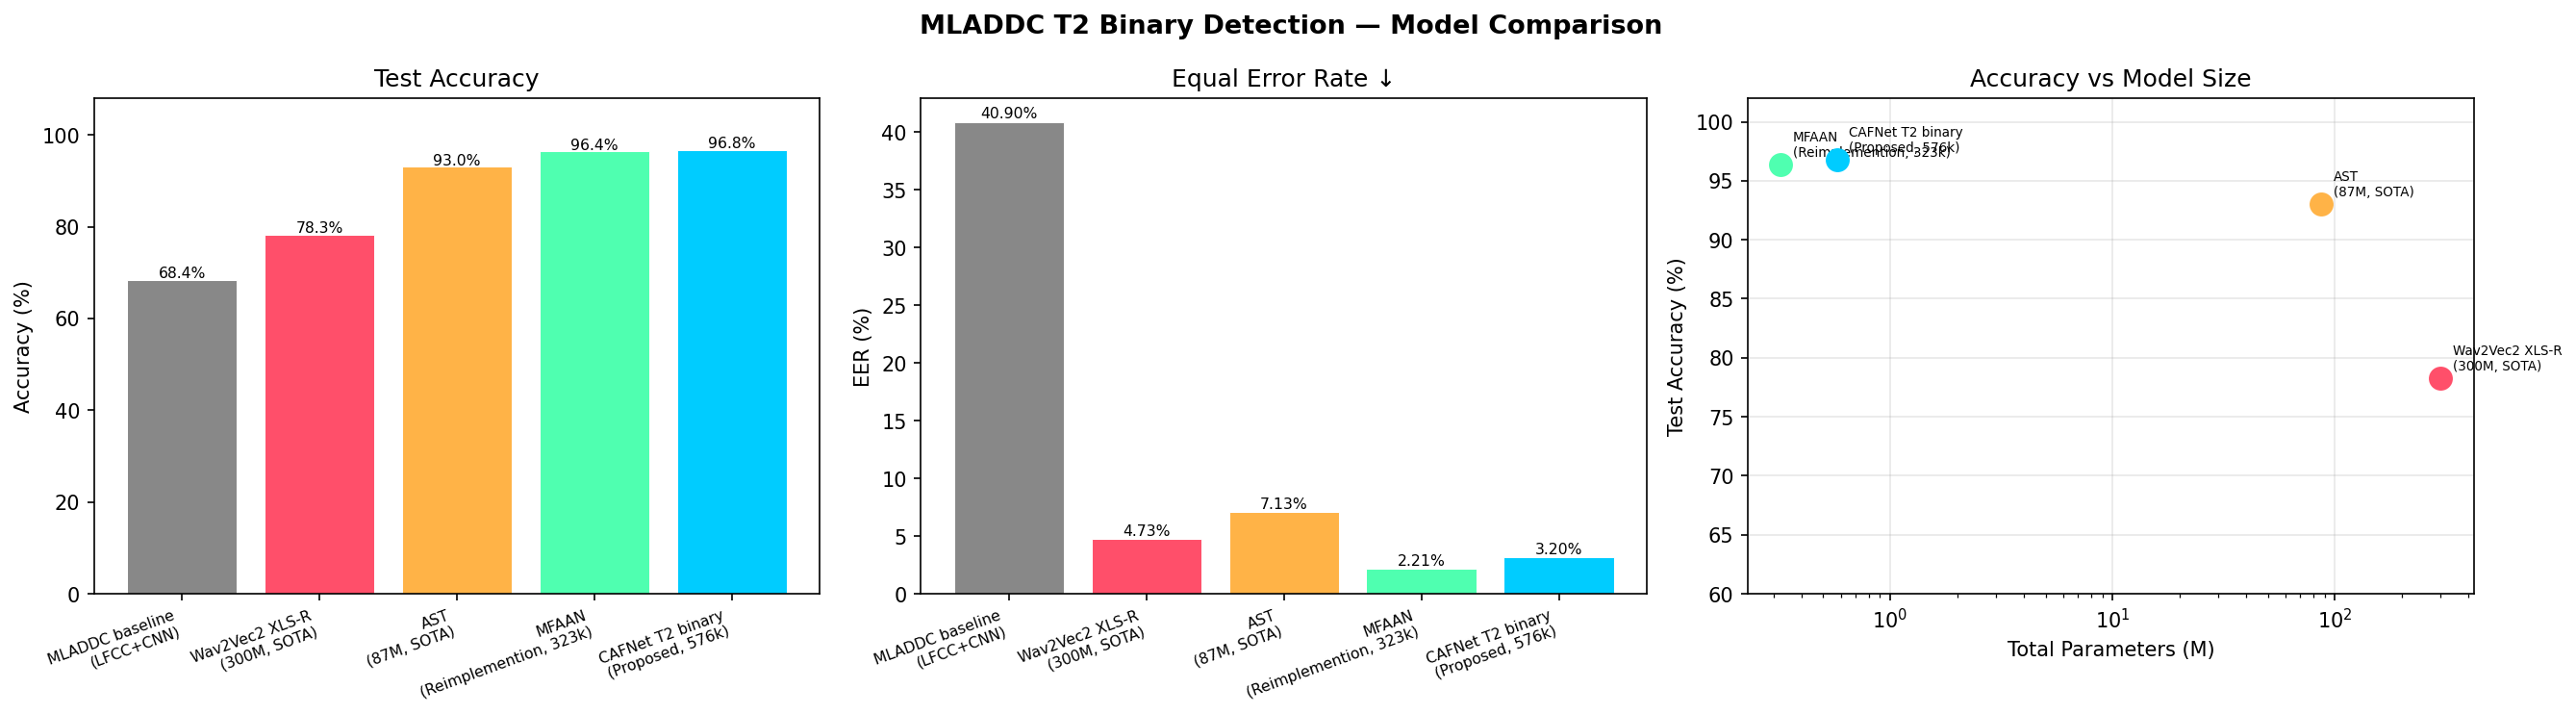

Saved: sota_comparison_plot.png


In [16]:
# ==============================================================================
# CELL 13: Comparison plots
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MLADDC T2 Binary Detection — Model Comparison',
             fontsize=13, fontweight='bold')

names  = [k.replace('\n', '\n') for k in results_all.keys()]
accs   = [v['acc'] * 100 for v in results_all.values()]
eers   = [v['eer'] * 100 for v in results_all.values()]
aucs   = [v['auc']       for v in results_all.values()]
params = [v['params']    for v in results_all.values()]
colors = ['#888888', '#ff4f6a', '#ffb347', '#4fffb0', '#00ccff', '#e8ff47']

x = range(len(names))

# ── Accuracy ──
bars = axes[0].bar(x, accs, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=7.5, rotation=20, ha='right')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Test Accuracy')
axes[0].set_ylim(0, 108)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=7.5)

# ── EER ──
bars2 = axes[1].bar(x, eers, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, fontsize=7.5, rotation=20, ha='right')
axes[1].set_ylabel('EER (%)')
axes[1].set_title('Equal Error Rate ↓')
for bar, val in zip(bars2, eers):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', fontsize=7.5)

# ── Params vs Accuracy scatter ──
for i, (name, r) in enumerate(results_all.items()):
    if r['params'] is None:
        continue
    axes[2].scatter(r['params'] / 1e6, r['acc'] * 100,
                    color=colors[i], s=120, zorder=5,
                    label=name.replace('\n', ' '))
    axes[2].annotate(name.replace('\n', '\n'),
                     (r['params'] / 1e6, r['acc'] * 100),
                     textcoords='offset points', xytext=(6, 4),
                     fontsize=6.5)
axes[2].set_xlabel('Total Parameters (M)')
axes[2].set_ylabel('Test Accuracy (%)')
axes[2].set_title('Accuracy vs Model Size')
axes[2].set_xscale('log')
axes[2].set_ylim(60, 102)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(WORK_DIR / 'sota_comparison_plot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sota_comparison_plot.png')